# Decoration Detection

Minimal notebook using `ManuscriptPage` and `DecorationModel` from `pipeline.decorations`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pipeline.decorations import ManuscriptPage, DecorationModel

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
image_name = "MS-GG-00001-00001-000-00021_double_more_complex_filigranes.jpg"
image_name = "MS-GG-00001-00001-000-00726_double_many_figures.jpg"
image_name = "MS-GG-00001-00001-000-00175_double_packed_center.jpg"
image_name = "MS-GG-00001-00001-000-01185_double_elements_stain.jpg"
# Path to the source image that was processed by the pipeline
IMAGE_PATH = Path("../data/exemplars/" + image_name)

BACKEND      = "medieval_yolo"   # 'medieval_yolo' | 'yolo' | 'florence2' | 'florence2_medieval'
SIZE         = "x"               # 'n' | 's' | 'm' | 'l' | 'x'  (medieval_yolo only)
CONFIDENCE   = 0.20

REMOVE_LINES    = False          # paint out text-line regions before detection
USE_FIGURE_MASK = False          # restrict detection to figure_binary regions

In [3]:
page = ManuscriptPage(IMAGE_PATH)
print(page)
print(f"Binding: {page.binding_side}  |  skew: {page.deskew_angle:.2f}°")
print(f"Lines: {page.n_lines}  |  Figures: {page.n_figures}")

ManuscriptPage('MS-GG-00001-00001-000-01185_double_elements_stain.jpg', 926×1409px, 74 lines)
Binding: left  |  skew: -1.50°
Lines: 74  |  Figures: 0


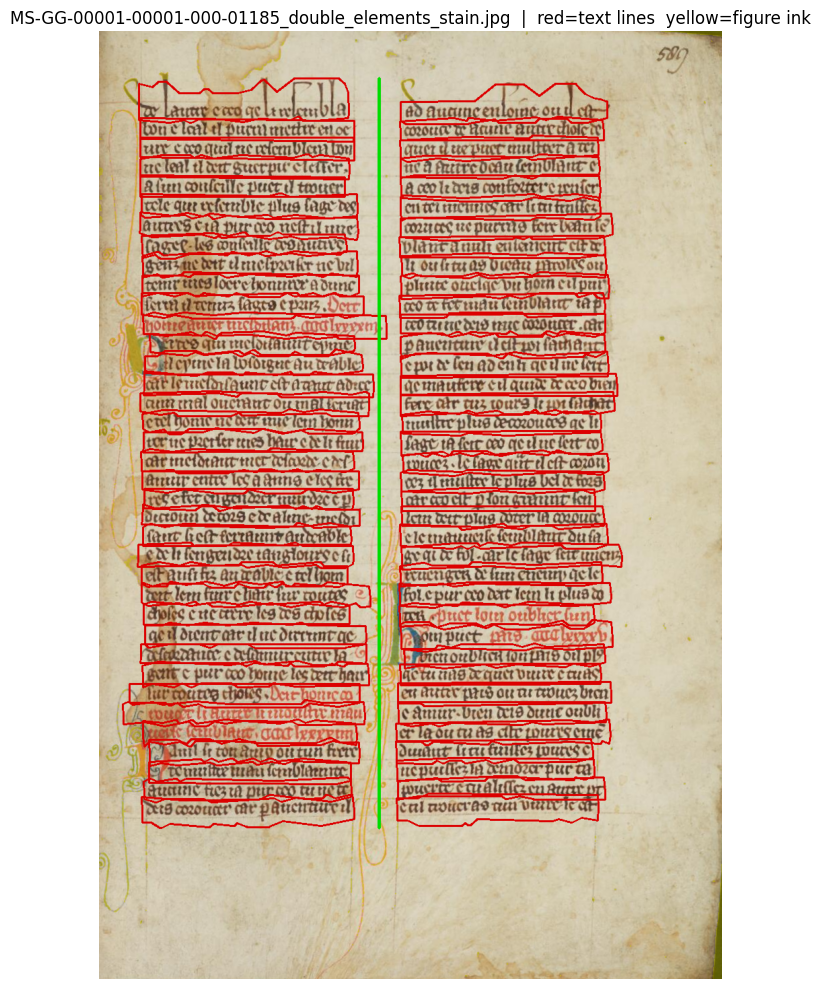

In [4]:
page.plot_raw()

In [5]:
model = DecorationModel(backend=BACKEND, size=SIZE, confidence_threshold=CONFIDENCE)

Device: mps


/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(cached after first run)
YOLO ready.  Classes: ['MarginTextZone', 'DefaultLine', 'MainZone', 'RunningTitleZone', 'NumberingZone', 'QuireMarksZone', 'HeadingLine', 'DropCapitalZone', 'StampZone', 'GraphicZone', 'InterlinearLine', 'DigitizationArtefactZone', 'DropCapitalLine', 'DamageZone', 'MusicLine', 'TitlePageZone', 'SealZone', 'MusicZone']


In [6]:
detections = model.run(page, remove_lines=REMOVE_LINES, use_figure_mask=USE_FIGURE_MASK)
print(f"{len(detections)} detections")

85 detections


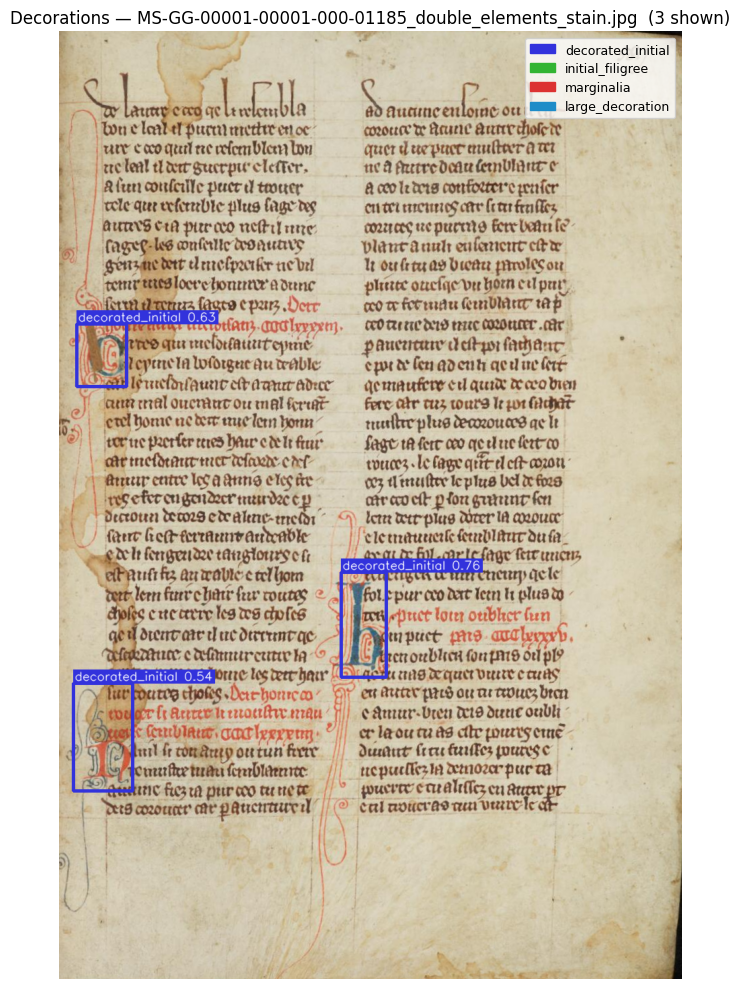

In [7]:
page.plot_detections(detections)

In [ ]:
page.plot_summary(detections)

In [ ]:
page.summarize(detections)

### Batch processing all files

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Path to the source image that was processed by the pipeline
FOLDER_PATH = Path("../data/exemplars/")

BACKEND      = "medieval_yolo"   # 'medieval_yolo' | 'yolo' | 'florence2' | 'florence2_medieval'
SIZE         = "x"               # 'n' | 's' | 'm' | 'l' | 'x'  (medieval_yolo only)
CONFIDENCE   = 0.20

REMOVE_LINES    = False          # paint out text-line regions before detection
USE_FIGURE_MASK = False          # restrict detection to figure_binary regions

RESULTS_FOLDER = Path("../results/explore_decorations")
RESULTS_FOLDER.mkdir(exist_ok=True, parents=True)

In [ ]:
model = DecorationModel(backend=BACKEND, size=SIZE, confidence_threshold=CONFIDENCE)

In [ ]:
all_images = sorted(FOLDER_PATH.glob("*.jpg"))
for img_path in all_images:
    print(f"\nProcessing {img_path.name}...")
    page = ManuscriptPage(img_path)
    detections = model.run(page, remove_lines=REMOVE_LINES, use_figure_mask=USE_FIGURE_MASK)
    print(f"  {len(detections)} detections")
    page.plot_detections(detections, save_dir = RESULTS_FOLDER)
    print(f"  Saved annotated image to: {RESULTS_FOLDER / img_path.name}")